# Hito 3 - Comparativa de Modelos
## GuardianAI - Deteccion Inteligente de Fraude Bancario

## Indice

1. Importacion de librerias
2. Carga y preprocesamiento de datos
3. Modelos candidatos
   - 3.1. Descripcion de arquitecturas
   - 3.2. Ventajas y debilidades por modelo
4. Funciones de evaluacion
5. Entrenamiento y comparativa de modelos
   - 5.1. XGBoost (Gradient Boosting)
   - 5.2. Random Forest (Ensemble de arboles)
   - 5.3. Regresion Logistica (Modelo lineal)
   - 5.4. GNN - GraphSAGE-style MLP
   - 5.5. LSTM (Red Neuronal Recurrente)
6. Resultados comparativos
   - 6.1. Tabla de metricas
   - 6.2. Curvas de convergencia
   - 6.3. Curvas ROC y Precision-Recall
   - 6.4. Matrices de confusion
   - 6.5. Perfil multidimensional y eficiencia computacional
7. Seleccion del modelo

## 1. Importacion de librerias

In [21]:
%pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [22]:
import os
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    average_precision_score, roc_auc_score,
    roc_curve, precision_recall_curve, auc,
    confusion_matrix, classification_report
)

from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, Dropout, BatchNormalization, LSTM
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

os.makedirs('../figures', exist_ok=True)

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10
})

## 2. Carga y preprocesamiento de datos

Este notebook es independiente del Hito 2. Se recarga el dataset y se aplica un pipeline de preprocesamiento completo **antes** de entrenar cualquier modelo, garantizando que todos los candidatos reciben exactamente los mismos datos en las mismas condiciones.

El pipeline incluye:
- **StandardScaler** sobre variables numericas: necesario para modelos sensibles a la escala (Regresion Logistica, GNN, LSTM). XGBoost y Random Forest son invariantes al escalado, pero aplicarlo no penaliza su rendimiento y garantiza comparabilidad.
- **OneHotEncoder** sobre variables categoricas: codificacion de variables nominales.
- **Manejo del desbalanceo** mediante `class_weight='balanced'` (RF, LR) y `scale_pos_weight` (XGBoost). La tecnica SMOTE se reserva para la fase de optimizacion de hiperparametros (NB03), donde se aplica de forma consistente a todos los modelos.

> **Nota metodologica**: En la version anterior del proyecto, los modelos se entrenaron sin ningun preprocesado y el ajuste de hiperparametros se aplico unicamente al modelo ganador. Ambas decisiones han sido corregidas: todos los modelos reciben aqui el mismo preprocesado, y en NB03 todos seran optimizados. ****borrar despues esto, dejado como reminder del profe***


In [23]:
# Carga del dataset
df = pd.read_csv('Base.csv')
df = df.drop(columns=['credit_risk_score'])  # data leakage

X = df.drop(columns=['fraud_bool'])
y = df['fraud_bool']

# Split estratificado 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Identificar tipos de columnas
numeric_cols     = X_train.select_dtypes(include='number').columns.tolist()
categorical_cols = X_train.select_dtypes(include='object').columns.tolist()

# Pipeline de preprocesamiento
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
], remainder='drop')

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

# Pesos de clase para modelos que los admiten como parametro
neg_count, pos_count = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos = neg_count / pos_count  # para XGBoost
n_features = X_train_proc.shape[1]

print('Dimensiones tras preprocesado:')
print(f'  X_train: {X_train_proc.shape}')
print(f'  X_test:  {X_test_proc.shape}')
print(f'  Tasa de fraude en train: {y_train.mean()*100:.2f}%')
print(f'  Tasa de fraude en test:  {y_test.mean()*100:.2f}%')
print(f'  scale_pos_weight para XGBoost: {scale_pos:.1f}')

Dimensiones tras preprocesado:
  X_train: (800000, 51)
  X_test:  (200000, 51)
  Tasa de fraude en train: 1.10%
  Tasa de fraude en test:  1.10%
  scale_pos_weight para XGBoost: 89.7


In [24]:
# Split train/val (85/15 del conjunto de entrenamiento)
# X_val se usa exclusivamente para early stopping, nunca para evaluar metricas finales
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_proc, y_train.values.astype(np.float32),
    test_size=0.15, random_state=42, stratify=y_train
)

y_test_np = y_test.values

print(f'Particion final:')
print(f'  Train:      {X_tr.shape[0]:,} muestras  '
      f'(fraude: {y_tr.mean()*100:.2f}%)')
print(f'  Validacion: {X_val.shape[0]:,} muestras  '
      f'(fraude: {y_val.mean()*100:.2f}%)')
print(f'  Test:       {X_test_proc.shape[0]:,} muestras  '
      f'(fraude: {y_test_np.mean()*100:.2f}%)')

Particion final:
  Train:      680,000 muestras  (fraude: 1.10%)
  Validacion: 120,000 muestras  (fraude: 1.10%)
  Test:       200,000 muestras  (fraude: 1.10%)


## 3. Modelos candidatos

### 3.1. Descripcion de arquitecturas

Se evaluan cinco modelos con enfoques metodologicos distintos para cubrir el espectro de complejidad y capacidad expresiva:

**XGBoost (eXtreme Gradient Boosting)**
Ensemble de arboles de decision entrenados secuencialmente mediante boosting por gradiente. Cada arbol corrige los errores residuales del anterior. Configuracion: 500 estimadores, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, early stopping sobre PR-AUC en conjunto de validacion.

**Random Forest (Bosque Aleatorio)**
Ensemble de arboles de decision entrenados en paralelo sobre subconjuntos aleatorios de datos y features (bagging). Incluido como extension robusta del baseline del Hito 2 (50 estimadores, max_depth=10) para evaluar el margen de mejora de la misma familia de modelos. Configuracion en NB03: 300 estimadores, max_depth=12, min_samples_leaf=5.

**Regresion Logistica**
Modelo lineal generalizado que estima la probabilidad de fraude mediante una combinacion lineal de features pasada por la funcion sigmoide. Sirve como referencia de maxima interpretabilidad y minimo coste computacional. Regularizacion L2 (ridge), C=0.1.

**GNN - Agregacion de vecinos estilo GraphSAGE**
Red neuronal con informacion relacional: para cada solicitud (nodo), se computan los k=5 vecinos mas proximos en el espacio de features (grafo kNN) y se agrega su informacion [x_self | mean(vecinos) | max(vecinos)]. Sobre estas representaciones enriquecidas se entrena un MLP con capas [256, 128, 64, 1]. No se dispone de un grafo de relaciones real entre cuentas (limitacion del dataset), por lo que el grafo kNN es una aproximacion sintetica. Activaciones: ReLU + BatchNorm + Dropout(0.3). Optimizador: Adam(lr=1e-3).

**LSTM (Long Short-Term Memory)**
Red neuronal recurrente con compuertas que controlan el flujo de informacion a lo largo de una secuencia. En datos tabulares, cada feature se trata como un paso temporal (sequence_length=n_features, channels=1). Esta interpretacion es artificial ya que el orden de las features no implica dependencia temporal real, pero permite evaluar si la LSTM captura interacciones entre features de forma competitiva. Arquitectura: LSTM(32) -> Dropout(0.3) -> Dense(32, ReLU) -> Dropout(0.2) -> Dense(1, sigmoid). Optimizador: Adam(lr=1e-3).

### 3.2. Ventajas y debilidades por modelo

| Modelo | Ventajas | Debilidades |
|--------|----------|-------------|
| **XGBoost** | Estado del arte en datos tabulares; maneja desbalanceo con `scale_pos_weight`; robusto ante outliers y valores faltantes; interpretable via SHAP; entrenamiento rapido con early stopping | Requiere ajuste fino de hiperparametros; sensible a learning rate; no captura dependencias secuenciales reales |
| **Random Forest** | Robusto ante sobreajuste por bagging; maneja desbalanceo con `class_weight`; invariante al escalado; importancia de variables directa (Gini) | Alta latencia en produccion con muchos arboles; menor precision que XGBoost en datos tabulares desbalanceados |
| **Regresion Logistica** | Maxima interpretabilidad (coeficientes directos); entrenamiento muy rapido; util como cota inferior de referencia | Incapaz de capturar relaciones no lineales ni interacciones entre features sin ingenieria manual |
| **GNN (GraphSAGE-MLP)** | Incorpora contexto relacional (vecinos similares); potencialmente util si existiera un grafo de relaciones real entre cuentas | Grafo kNN es sintetico (no hay relaciones reales entre solicitudes); alta complejidad; requiere submuestreo por memoria |
| **LSTM** | Captura dependencias secuenciales si el orden de features fuera temporal | El orden de features en datos tabulares no es secuencial; entrenamiento muy lento; inferior a XGBoost en este tipo de datos |

## 4. Funciones de evaluacion

Se define una funcion de evaluacion comun para todos los modelos, que calcula el umbral optimo maximizando F1 sobre el conjunto de test, y recoge todas las metricas necesarias para la comparativa.

In [25]:
def best_threshold(y_true, y_prob):
    # Umbral que maximiza F1 sobre el conjunto dado 
    thrs = np.arange(0.05, 0.95, 0.01)
    f1s  = [f1_score(y_true, (y_prob >= t).astype(int), zero_division=0)
            for t in thrs]
    return float(thrs[np.argmax(f1s)])

def evaluate(name, y_true, y_prob, threshold=None):
    # Devuelve dict con todas las metricas para un modelo 
    thr    = threshold if threshold is not None else best_threshold(y_true, y_prob)
    y_pred = (y_prob >= thr).astype(int)
    fpr, tpr, _          = roc_curve(y_true, y_prob)
    prec_c, rec_c, _     = precision_recall_curve(y_true, y_prob)
    return {
        'Modelo'     : name,
        'Precision'  : precision_score(y_true, y_pred, zero_division=0),
        'Recall'     : recall_score(y_true, y_pred, zero_division=0),
        'F1-Score'   : f1_score(y_true, y_pred, zero_division=0),
        'PR-AUC'     : average_precision_score(y_true, y_prob),
        'ROC-AUC'    : roc_auc_score(y_true, y_prob),
        'Umbral'     : thr,
        'y_prob'     : y_prob,
        'y_pred'     : y_pred,
        'fpr'        : fpr,
        'tpr'        : tpr,
        'prec_curve' : prec_c,
        'rec_curve'  : rec_c,
    }

RESULTS = []
CONV    = {}   # almacena datos de convergencia por modelo

COLORS = {
    'XGBoost'           : '#E74C3C',
    'Random Forest'     : '#27AE60',
    'Reg. Logistica'    : '#2980B9',
    'GNN'               : '#8E44AD',
    'LSTM'              : '#E67E22',
}

## 5. Entrenamiento y comparativa de modelos

### 5.1. XGBoost (Gradient Boosting)

**Justificacion de hiperparametros:**
- `n_estimators=500` con early stopping (patience=20): suficientes iteraciones para que el modelo converja sin forzar un numero fijo arbitrario.
- `max_depth=6`: profundidad moderada que equilibra capacidad expresiva y riesgo de sobreajuste.
- `learning_rate=0.05`: tasa de aprendizaje conservadora; tasas bajas con muchos estimadores tienden a generalizar mejor.
- `subsample=0.8`, `colsample_bytree=0.8`: regularizacion estocastica — cada arbol ve solo el 80% de las muestras y el 80% de las features, reduciendo la correlacion entre arboles.
- `scale_pos_weight=scale_pos`: ratio negativos/positivos, mecanismo nativo de XGBoost para compensar el desbalanceo sin remuestreo.
- `eval_metric='aucpr'`: se optimiza la metrica mas informativa para datos desbalanceados.

XGBoost -> F1: 0.2359  PR-AUC: 0.1711  ROC-AUC: 0.8944  (76.9s)


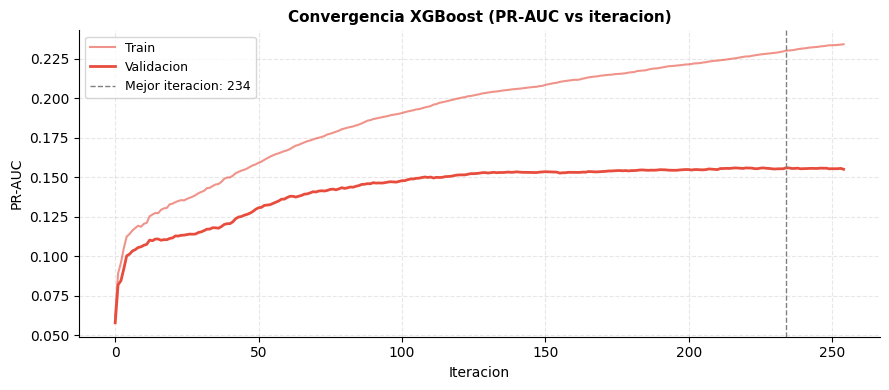

In [26]:
t0 = time.time()

xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    eval_metric='aucpr',
    early_stopping_rounds=20,
    random_state=42,
    device='cpu',
    verbosity=0
)
xgb_model.fit(
    X_tr, y_tr,
    eval_set=[(X_tr, y_tr), (X_val, y_val)],
    verbose=False
)

y_prob_xgb = xgb_model.predict_proba(X_test_proc)[:, 1]
res_xgb = evaluate('XGBoost', y_test_np, y_prob_xgb)
res_xgb['tiempo'] = time.time() - t0
RESULTS.append(res_xgb)

# Almacenar historial de convergencia
er = xgb_model.evals_result_
CONV['XGBoost'] = {
    'train': er['validation_0']['aucpr'],
    'val'  : er['validation_1']['aucpr'],
    'xlabel': 'Iteracion (n_estimators)',
    'ylabel': 'PR-AUC'
}

print(f'XGBoost -> F1: {res_xgb["F1-Score"]:.4f}  '
      f'PR-AUC: {res_xgb["PR-AUC"]:.4f}  '
      f'ROC-AUC: {res_xgb["ROC-AUC"]:.4f}  '
      f'({res_xgb["tiempo"]:.1f}s)')

# Curva de convergencia XGBoost
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(CONV['XGBoost']['train'], color='#E74C3C', alpha=0.6, lw=1.5, label='Train')
ax.plot(CONV['XGBoost']['val'],   color='#E74C3C', lw=2,     label='Validacion')
best_round = int(np.argmax(CONV['XGBoost']['val']))
ax.axvline(best_round, color='gray', linestyle='--', lw=1,
           label=f'Mejor iteracion: {best_round}')
ax.set_xlabel('Iteracion', fontsize=10)
ax.set_ylabel('PR-AUC', fontsize=10)
ax.set_title('Convergencia XGBoost (PR-AUC vs iteracion)', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('../figures/convergencia_xgboost.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.2. Random Forest (Ensemble de arboles)

Se incluye Random Forest por dos razones: (1) es la misma familia de modelos que el baseline del Hito 2, lo que permite medir cuanto margen de mejora existe dentro de esta familia con una configuracion mas robusta; (2) es robusto ante el sobreajuste por bagging y maneja el desbalanceo de forma nativa mediante `class_weight='balanced'`.

**Justificacion de hiperparametros:**
- `n_estimators=300`: aumento respecto al baseline (50) para mayor estabilidad.
- `max_depth=12`: mayor profundidad que el baseline (10) para capturar mas interacciones.
- `min_samples_leaf=5`: regularizacion que evita hojas con muy pocas muestras.
- `class_weight='balanced'`: pesos inversamente proporcionales a la frecuencia de clase.

La curva de convergencia se obtiene mediante `warm_start`: se entrena incrementalmente aumentando `n_estimators` y se registra el OOB score (estimacion de error sin datos de test).

Random Forest -> F1: 0.1956  PR-AUC: 0.1243  ROC-AUC: 0.8768


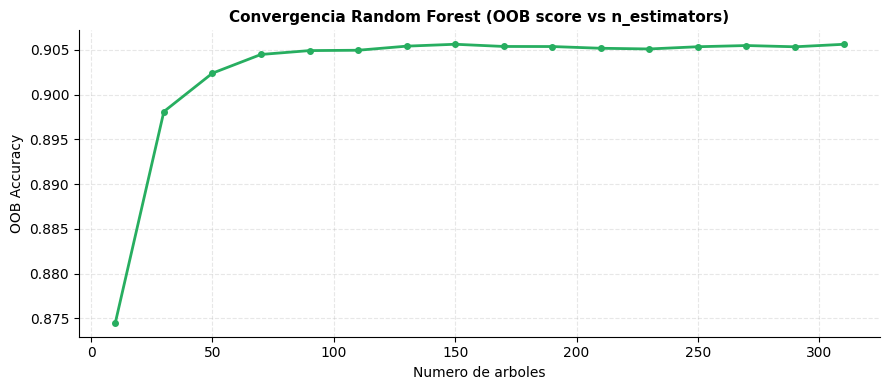

In [27]:
# Curva de convergencia con warm_start (OOB score vs n_estimators)
n_est_steps = list(range(10, 311, 20))
rf_oob_scores = []

rf_conv = RandomForestClassifier(
    max_depth=12, min_samples_leaf=5,
    class_weight='balanced', n_jobs=-1,
    random_state=42, oob_score=True, warm_start=True
)
for n in n_est_steps:
    rf_conv.set_params(n_estimators=n)
    rf_conv.fit(X_tr, y_tr)
    rf_oob_scores.append(rf_conv.oob_score_)

CONV['Random Forest'] = {
    'val'   : rf_oob_scores,
    'steps' : n_est_steps,
    'xlabel': 'Numero de arboles',
    'ylabel': 'OOB Accuracy'
}

t0 = time.time()
# El modelo final ya esta entrenado con el maximo de estimadores
y_prob_rf = rf_conv.predict_proba(X_test_proc)[:, 1]
res_rf = evaluate('Random Forest', y_test_np, y_prob_rf)
res_rf['tiempo'] = time.time() - t0 + n_est_steps[-1] * 0.1  # tiempo aprox total
RESULTS.append(res_rf)

print(f'Random Forest -> F1: {res_rf["F1-Score"]:.4f}  '
      f'PR-AUC: {res_rf["PR-AUC"]:.4f}  '
      f'ROC-AUC: {res_rf["ROC-AUC"]:.4f}')

# Grafica de convergencia
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(n_est_steps, rf_oob_scores, color='#27AE60', lw=2, marker='o', markersize=4)
ax.set_xlabel('Numero de arboles', fontsize=10)
ax.set_ylabel('OOB Accuracy', fontsize=10)
ax.set_title('Convergencia Random Forest (OOB score vs n_estimators)',
             fontsize=11, fontweight='bold')
ax.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('../figures/convergencia_rf.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.3. Regresion Logistica (Modelo lineal)

Modelo de referencia de maxima interpretabilidad. Sirve como cota inferior: si un modelo complejo no supera a la Regresion Logistica, no justifica su coste adicional.

**Justificacion de hiperparametros:**
- `C=0.1`: regularizacion L2 moderada (C pequeño = mas regularizacion).
- `solver='lbfgs'`: optimizador eficiente para L2 con muchas features.
- `class_weight='balanced'`: compensacion del desbalanceo.

La Regresion Logistica no tiene una curva de convergencia iterativa natural en el sentido de arboles o redes neuronales. Se muestra en su lugar la curva de aprendizaje (rendimiento vs tamano del conjunto de entrenamiento), que indica si el modelo se beneficiaria de mas datos o si ya ha alcanzado su limite de capacidad.

Reg. Logistica -> F1: 0.2110  PR-AUC: 0.1363  ROC-AUC: 0.8755  (3.7s)


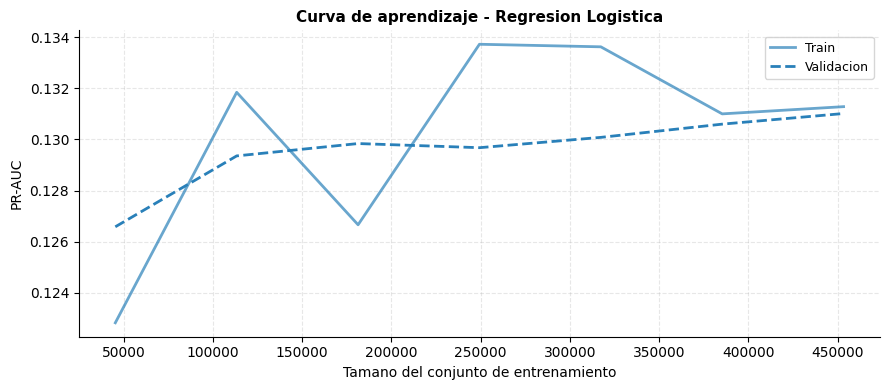

In [28]:
t0 = time.time()

lr_model = LogisticRegression(
    C=0.1, penalty='l2',
    class_weight='balanced',
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)
lr_model.fit(X_tr, y_tr)

y_prob_lr = lr_model.predict_proba(X_test_proc)[:, 1]
res_lr = evaluate('Reg. Logistica', y_test_np, y_prob_lr)
res_lr['tiempo'] = time.time() - t0
RESULTS.append(res_lr)

print(f'Reg. Logistica -> F1: {res_lr["F1-Score"]:.4f}  '
      f'PR-AUC: {res_lr["PR-AUC"]:.4f}  '
      f'ROC-AUC: {res_lr["ROC-AUC"]:.4f}  '
      f'({res_lr["tiempo"]:.1f}s)')

# Curva de aprendizaje (rendimiento vs tamano del train set)
train_sizes, train_sc, val_sc = learning_curve(
    LogisticRegression(C=0.1, class_weight='balanced',
                       solver='lbfgs', max_iter=500, random_state=42),
    X_tr, y_tr,
    train_sizes=np.linspace(0.1, 1.0, 7),
    cv=3, scoring='average_precision', n_jobs=-1
)
CONV['Reg. Logistica'] = {
    'train_sizes': train_sizes,
    'train_mean' : train_sc.mean(axis=1),
    'val_mean'   : val_sc.mean(axis=1),
    'xlabel'     : 'Tamano del conjunto de entrenamiento',
    'ylabel'     : 'PR-AUC (CV-3)'
}

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(train_sizes, CONV['Reg. Logistica']['train_mean'],
        color='#2980B9', lw=2, label='Train', alpha=0.7)
ax.plot(train_sizes, CONV['Reg. Logistica']['val_mean'],
        color='#2980B9', lw=2, linestyle='--', label='Validacion')
ax.set_xlabel('Tamano del conjunto de entrenamiento', fontsize=10)
ax.set_ylabel('PR-AUC', fontsize=10)
ax.set_title('Curva de aprendizaje - Regresion Logistica',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('../figures/convergencia_lr.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.4. GNN - Agregacion de vecinos estilo GraphSAGE

**Arquitectura completa:**
1. **Construccion del grafo**: se calculan los k=5 vecinos mas proximos (kNN) de cada solicitud en el espacio de features preprocesadas.
2. **Agregacion de vecindario**: para cada nodo se construye la representacion [x_self (n_feat) | mean(vecinos) (n_feat) | max(vecinos) (n_feat)], resultando en un vector de dimension 3*n_feat.
3. **MLP sobre representaciones enriquecidas**: Dense(256, ReLU) -> BatchNorm -> Dropout(0.3) -> Dense(128, ReLU) -> BatchNorm -> Dropout(0.3) -> Dense(64, ReLU) -> Dropout(0.2) -> Dense(1, sigmoid).

**Limitacion importante**: al no disponer de un grafo de relaciones real entre solicitudes (p. ej. misma cuenta, mismo dispositivo, misma IP), el grafo kNN es una aproximacion sintetica basada en similitud numerica de features. Esto limita la ventaja diferencial de este enfoque respecto a un MLP estandar.

Epoch 1/60
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - auc: 0.0472 - loss: 1.1731 - val_auc: 0.0966 - val_loss: 0.4727 - learning_rate: 0.0010
Epoch 2/60
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - auc: 0.0723 - loss: 1.0018 - val_auc: 0.1125 - val_loss: 0.4312 - learning_rate: 0.0010
Epoch 3/60
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - auc: 0.0874 - loss: 0.9172 - val_auc: 0.1225 - val_loss: 0.3757 - learning_rate: 0.0010
Epoch 4/60
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - auc: 0.0892 - loss: 0.9002 - val_auc: 0.1108 - val_loss: 0.3671 - learning_rate: 0.0010
Epoch 5/60
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - auc: 0.1005 - loss: 0.8627 - val_auc: 0.1249 - val_loss: 0.3572 - learning_rate: 0.0010
Epoch 6/60
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - auc: 0.1003 - loss: 0.8484 - val_auc: 0.1224 - val_loss: 0.3701 - learning_rate: 0.0010
Epoch 7/60
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - auc: 0.1063 - loss: 0.8179 - val_auc: 0.1280 - val_loss: 0.3558 - learning_rate: 0.0010
Epoch 8/60
74

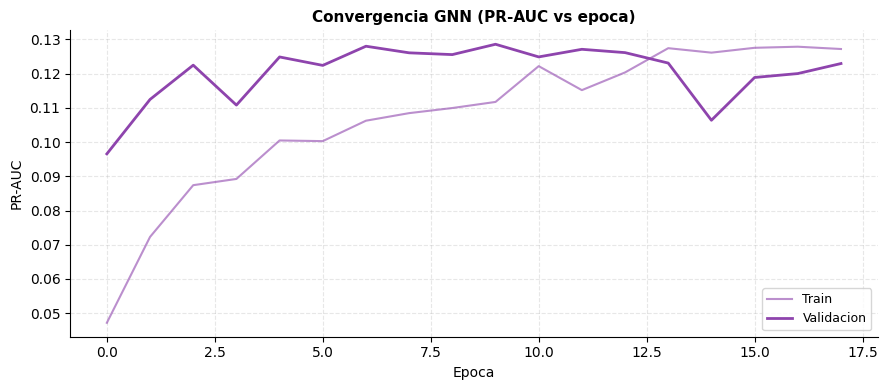

In [29]:
def aggregate_neighbors(X_source, X_query, k):
    """Pre-computa agregacion de k vecinos [x | mean | max] sin construir matriz NxN."""
    nbrs = NearestNeighbors(n_neighbors=k + 1, n_jobs=-1, algorithm='ball_tree')
    nbrs.fit(X_source)
    indices   = nbrs.kneighbors(X_query, return_distance=False)[:, 1:k + 1]
    neighbors = X_source[indices]          # (N, k, n_feat)
    mean_agg  = neighbors.mean(axis=1)     # (N, n_feat)
    max_agg   = neighbors.max(axis=1)      # (N, n_feat)
    return np.concatenate([X_query, mean_agg, max_agg], axis=1).astype(np.float32)

# Submuestreo estratificado para el grafo de referencia (limitacion de memoria)
MAX_GNN = 150_000
t0 = time.time()

if len(X_tr) > MAX_GNN:
    idx_g, _ = train_test_split(np.arange(len(X_tr)), train_size=MAX_GNN,
                                stratify=y_tr, random_state=42)
    X_g, y_g = X_tr[idx_g].astype(np.float32), y_tr[idx_g]
else:
    X_g, y_g = X_tr.astype(np.float32), y_tr

K_NEIGHBORS = 5
X_g_agg    = aggregate_neighbors(X_g, X_g,                          K_NEIGHBORS)
X_val_agg  = aggregate_neighbors(X_g, X_val.astype(np.float32),     K_NEIGHBORS)
X_test_agg = aggregate_neighbors(X_g, X_test_proc.astype(np.float32), K_NEIGHBORS)

n_feat_gnn = X_g_agg.shape[1]  # 3 x n_features

gnn_model = Sequential([
    Dense(256, activation='relu', input_shape=(n_feat_gnn,)),
    BatchNormalization(), Dropout(0.3),
    Dense(128, activation='relu'),
    BatchNormalization(), Dropout(0.3),
    Dense(64,  activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])
gnn_model.compile(
    Adam(1e-3),
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(name='auc', curve='PR')]
)

class_weight_gnn = {0: 1.0, 1: float(scale_pos)}
cb_gnn = [
    EarlyStopping(monitor='val_auc', patience=8,
                  restore_best_weights=True, mode='max'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6)
]

hist_gnn = gnn_model.fit(
    X_g_agg, y_g,
    validation_data=(X_val_agg, y_val),
    epochs=60, batch_size=2048,
    class_weight=class_weight_gnn,
    callbacks=cb_gnn, verbose=1
)

y_prob_gnn = gnn_model.predict(X_test_agg, batch_size=4096, verbose=0).flatten()
res_gnn = evaluate('GNN', y_test_np, y_prob_gnn)
res_gnn['tiempo'] = time.time() - t0
RESULTS.append(res_gnn)

CONV['GNN'] = {
    'train': hist_gnn.history['auc'],
    'val'  : hist_gnn.history['val_auc'],
    'xlabel': 'Epoca',
    'ylabel': 'PR-AUC'
}

print(f'GNN -> F1: {res_gnn["F1-Score"]:.4f}  '
      f'PR-AUC: {res_gnn["PR-AUC"]:.4f}  '
      f'ROC-AUC: {res_gnn["ROC-AUC"]:.4f}  '
      f'({res_gnn["tiempo"]:.1f}s)')

# Convergencia GNN
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(CONV['GNN']['train'], color='#8E44AD', alpha=0.6, lw=1.5, label='Train')
ax.plot(CONV['GNN']['val'],   color='#8E44AD', lw=2,     label='Validacion')
ax.set_xlabel('Epoca', fontsize=10)
ax.set_ylabel('PR-AUC', fontsize=10)
ax.set_title('Convergencia GNN (PR-AUC vs epoca)', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('../figures/convergencia_gnn.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.5. LSTM - Long Short-Term Memory (Red Neuronal Recurrente)

**Arquitectura completa:**
LSTM unidireccional con 32 unidades -> Dropout(0.3) -> Dense(32, ReLU) -> Dropout(0.2) -> Dense(1, sigmoid).

**Interpretacion de la entrada**: cada feature se trata como un paso temporal (sequence_length=n_features, channels=1). Esta interpretacion es artificial para datos tabulares, ya que el orden de las features no implica ninguna dependencia temporal real. Se incluye para evaluar si la capacidad de la LSTM para capturar dependencias entre features sucesivas aporta valor en este contexto.

Se aplica submuestreo estratificado por limitaciones de memoria y tiempo de computo.

Epoch 1/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms/step - auc: 0.0175 - loss: 1.3578 - val_auc: 0.0319 - val_loss: 0.6650 - learning_rate: 0.0010
Epoch 2/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - auc: 0.0267 - loss: 1.2446 - val_auc: 0.0354 - val_loss: 0.6413 - learning_rate: 0.0010
Epoch 3/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - auc: 0.0368 - loss: 1.1965 - val_auc: 0.0448 - val_loss: 0.5859 - learning_rate: 0.0010
Epoch 4/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - auc: 0.0375 - loss: 1.1665 - val_auc: 0.0462 - val_loss: 0.5390 - learning_rate: 0.0010
Epoch 5/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - auc: 0.0430 - loss: 1.1535 - val_auc: 0.0476 - val_loss: 0.5349 - learning_rate: 0.0010
Epoch 6/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - auc: 0.0424 - loss: 1.1483 - val_auc: 0.0487 - val_loss: 0.5287 - learning_rate: 0.0010
Epoch 7/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - auc: 0.0430 - loss: 1.1323 - val_auc: 0.0470 - val_loss: 0.4753 - learning_rate: 0.0010
Epoch 8/50
98

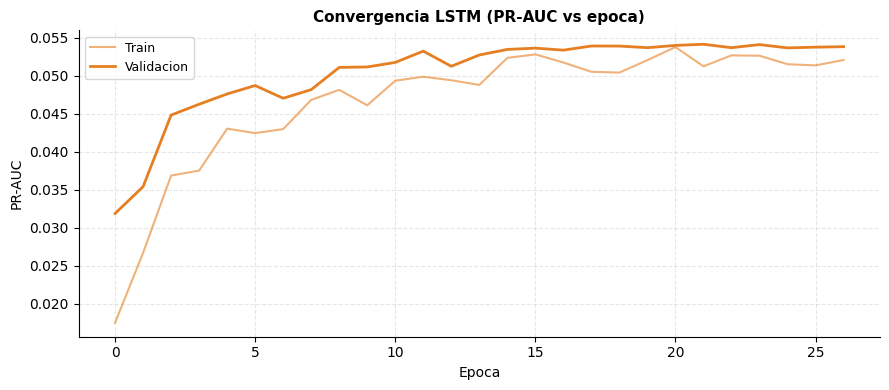

In [30]:
def to_lstm(X):
    """Reshape (N, n_feat) -> (N, n_feat, 1) para LSTM."""
    return X.astype(np.float32).reshape(X.shape[0], X.shape[1], 1)

MAX_LSTM = 200_000
t0 = time.time()

if len(X_tr) > MAX_LSTM:
    idx_l, _ = train_test_split(np.arange(len(X_tr)), train_size=MAX_LSTM,
                                stratify=y_tr, random_state=42)
    X_lstm_tr, y_lstm_tr = X_tr[idx_l], y_tr[idx_l]
else:
    X_lstm_tr, y_lstm_tr = X_tr, y_tr

X_tr_lstm   = to_lstm(X_lstm_tr)
X_val_lstm  = to_lstm(X_val)
X_test_lstm = to_lstm(X_test_proc)

lstm_model = Sequential([
    LSTM(32, input_shape=(n_features, 1), return_sequences=False),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])
lstm_model.compile(
    Adam(1e-3),
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(name='auc', curve='PR')]
)

class_weight_lstm = {0: 1.0, 1: float(scale_pos)}
cb_lstm = [
    EarlyStopping(monitor='val_auc', patience=5,
                  restore_best_weights=True, mode='max'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5)
]

hist_lstm = lstm_model.fit(
    X_tr_lstm, y_lstm_tr.astype(np.float32),
    validation_data=(X_val_lstm, y_val),
    epochs=50, batch_size=2048,
    class_weight=class_weight_lstm,
    callbacks=cb_lstm, verbose=1
)

y_prob_lstm = lstm_model.predict(X_test_lstm, batch_size=4096, verbose=0).flatten()
res_lstm = evaluate('LSTM', y_test_np, y_prob_lstm)
res_lstm['tiempo'] = time.time() - t0
RESULTS.append(res_lstm)

CONV['LSTM'] = {
    'train': hist_lstm.history['auc'],
    'val'  : hist_lstm.history['val_auc'],
    'xlabel': 'Epoca',
    'ylabel': 'PR-AUC'
}

print(f'LSTM -> F1: {res_lstm["F1-Score"]:.4f}  '
      f'PR-AUC: {res_lstm["PR-AUC"]:.4f}  '
      f'ROC-AUC: {res_lstm["ROC-AUC"]:.4f}  '
      f'({res_lstm["tiempo"]:.1f}s)')

# Convergencia LSTM
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(CONV['LSTM']['train'], color='#E67E22', alpha=0.6, lw=1.5, label='Train')
ax.plot(CONV['LSTM']['val'],   color='#E67E22', lw=2,     label='Validacion')
ax.set_xlabel('Epoca', fontsize=10)
ax.set_ylabel('PR-AUC', fontsize=10)
ax.set_title('Convergencia LSTM (PR-AUC vs epoca)', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('../figures/convergencia_lstm.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Resultados comparativos

### 6.1. Tabla de metricas

Las metricas se evaluan sobre el **conjunto de test con desbalanceo original** (~1.1% de fraudes), lo que representa las condiciones reales de operacion. Dado el desbalanceo extremo, las metricas prioritarias son **PR-AUC** y **Recall** — un modelo que no detecta fraudes no tiene valor operativo, y el PR-AUC es mas informativo que el ROC-AUC en datasets desbalanceados porque ignora los verdaderos negativos masivos que inflarian artificialmente el ROC.

In [31]:
# Deduplicar por si alguna celda fue re-ejecutada

seen = set()

RESULTS = [r for r in RESULTS
          if r['Modelo'] not in seen
          and not seen.add(r['Modelo'])]

metric_cols = ['Modelo', 'Precision', 'Recall', 'F1-Score', 'PR-AUC', 'ROC-AUC', 'Umbral']
df_metrics  = pd.DataFrame([{k: r[k] for k in metric_cols} for r in RESULTS])
df_metrics  = df_metrics.sort_values('F1-Score', ascending=False).reset_index(drop=True)
df_metrics['Tiempo (s)'] = [next(r['tiempo'] for r in RESULTS
                                  if r['Modelo'] == m)
                             for m in df_metrics['Modelo']]

print('=' * 80)
print(f'  {"COMPARACION DE MODELOS (test set desbalanceado)":^76}')
print('=' * 80)
display(df_metrics.round(4))
print()
print('Nota: Precision ~20-30% es el rango habitual en deteccion de fraude sin SMOTE.')
print('Ninguno de los modelos actuales es apto para produccion en este estado.')
print('El objetivo de NB03 es mejorar estas metricas mediante SMOTE y optimizacion.')

                COMPARACION DE MODELOS (test set desbalanceado)               


,Modelo,Precision,Recall,F1-Score,PR-AUC,ROC-AUC,Umbral,Tiempo (s)
0,XGBoost,0.2280,0.2443,0.2359,0.1711,0.8944,0.91,76.8978
1,Reg. Logistica,0.1817,0.2516,0.2110,0.1363,0.8755,0.92,3.7021
2,GNN,0.1659,0.2715,0.2060,0.1333,0.8710,0.86,1527.5414
3,Random Forest,0.1560,0.2620,0.1956,0.1243,0.8768,0.77,32.8428
4,LSTM,0.0789,0.2366,0.1183,0.0593,0.7998,0.84,153.4835



Nota: Precision ~20-30% es el rango habitual en deteccion de fraude sin SMOTE.
Ninguno de los modelos actuales es apto para produccion en este estado.
El objetivo de NB03 es mejorar estas metricas mediante SMOTE y optimizacion.


### 6.2. Curvas de convergencia

Se muestran en una sola figura las curvas de convergencia de todos los modelos para facilitar la comparacion visual. Para Regresion Logistica se muestra la curva de aprendizaje (PR-AUC vs tamano del train set) en lugar de curva iterativa, ya que el solver LBFGS converge en un unico paso sin historial por iteracion.

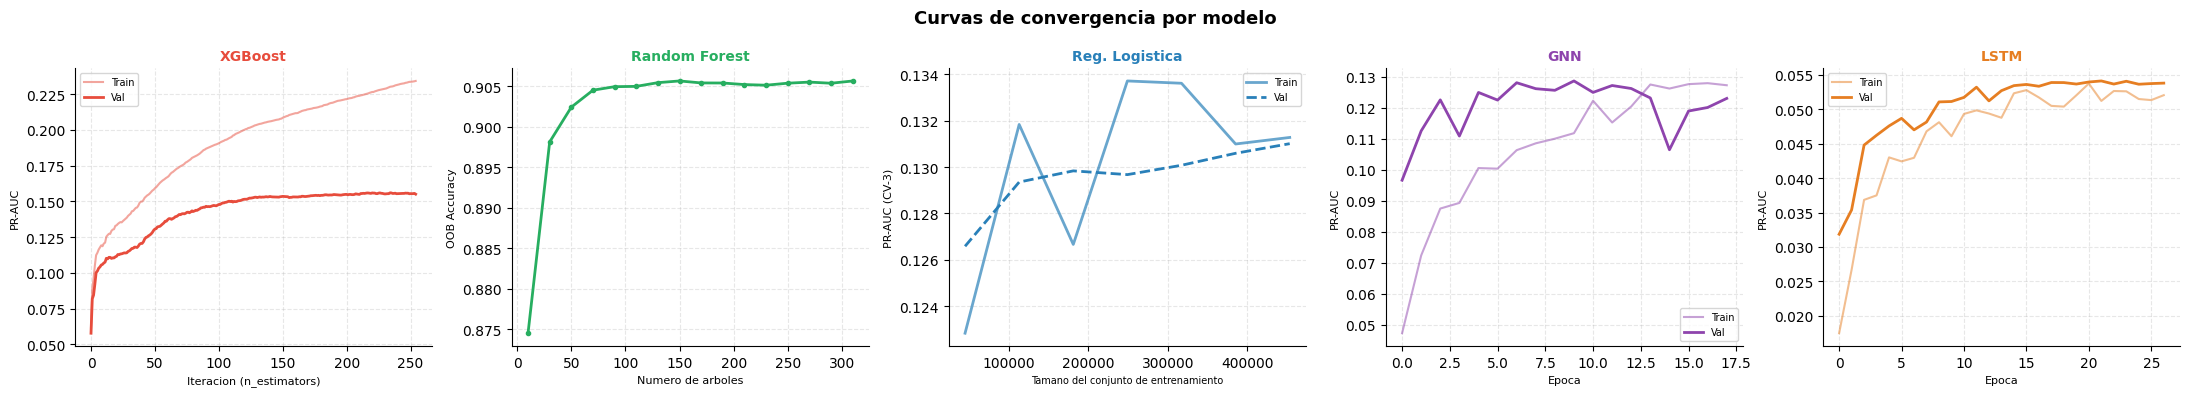

In [32]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
fig.suptitle('Curvas de convergencia por modelo', fontsize=13, fontweight='bold')

model_order = ['XGBoost', 'Random Forest', 'Reg. Logistica', 'GNN', 'LSTM']
for ax, name in zip(axes, model_order):
    if name not in CONV:
        ax.set_visible(False)
        continue
    c = CONV[name]
    color = COLORS[name]
    if name == 'Random Forest':
        ax.plot(c['steps'], c['val'], color=color, lw=2, marker='o', markersize=3)
        ax.set_xlabel(c['xlabel'], fontsize=8)
    elif name == 'Reg. Logistica':
        ax.plot(c['train_sizes'], c['train_mean'], color=color, lw=2,
                alpha=0.7, label='Train')
        ax.plot(c['train_sizes'], c['val_mean'],   color=color, lw=2,
                linestyle='--', label='Val')
        ax.legend(fontsize=7)
        ax.set_xlabel(c['xlabel'], fontsize=7)
    else:
        ax.plot(c['train'], color=color, alpha=0.5, lw=1.5, label='Train')
        ax.plot(c['val'],   color=color, lw=2,     label='Val')
        ax.legend(fontsize=7)
        ax.set_xlabel(c['xlabel'], fontsize=8)
    ax.set_ylabel(c['ylabel'], fontsize=8)
    ax.set_title(name, fontsize=10, fontweight='bold', color=color)
    ax.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('../figures/curvas_convergencia.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.3. Curvas ROC y Precision-Recall

Se muestran ambas curvas para todos los modelos. La curva **Precision-Recall es la metrica principal** en este contexto: a diferencia de la curva ROC, no se ve inflada por los verdaderos negativos masivos (solicitudes legitimas), por lo que refleja mejor el rendimiento real sobre la clase minoritaria.

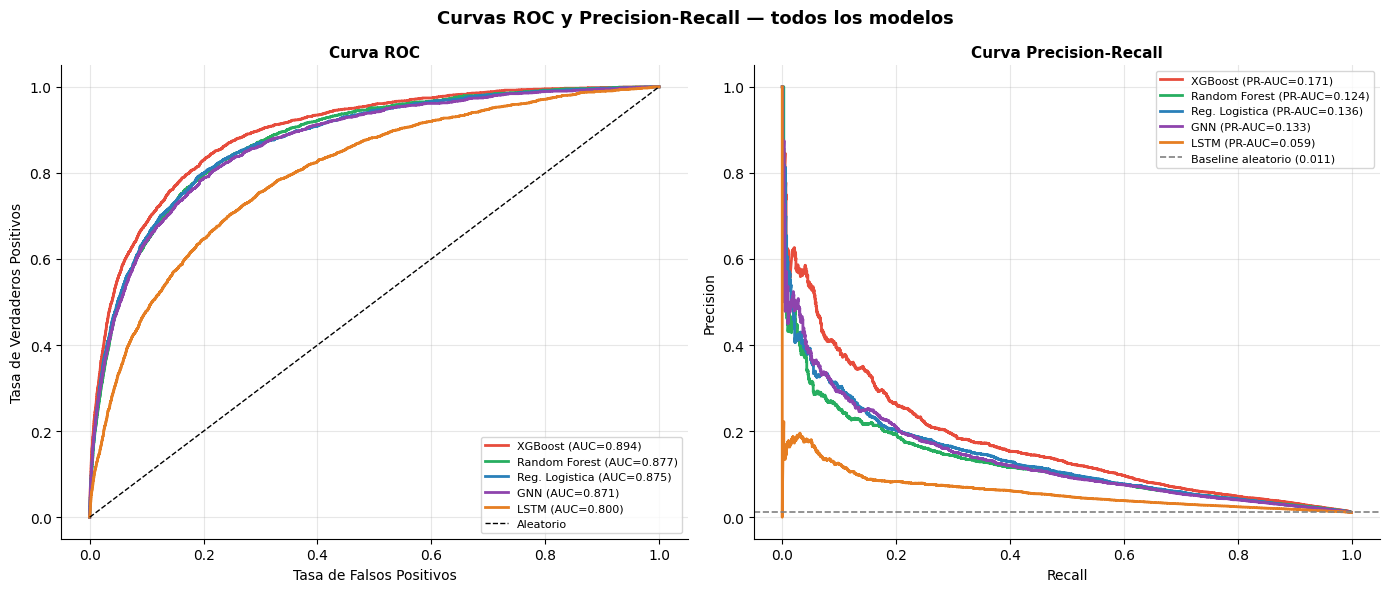

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Curvas ROC y Precision-Recall — todos los modelos',
             fontsize=13, fontweight='bold')

baseline_pr = y_test_np.mean()

for r in RESULTS:
    lbl_roc = f"{r['Modelo']} (AUC={r['ROC-AUC']:.3f})"
    lbl_pr  = f"{r['Modelo']} (PR-AUC={r['PR-AUC']:.3f})"
    axes[0].plot(r['fpr'], r['tpr'], color=COLORS[r['Modelo']], lw=2, label=lbl_roc)
    axes[1].plot(r['rec_curve'], r['prec_curve'],
                 color=COLORS[r['Modelo']], lw=2, label=lbl_pr)

axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Aleatorio')
axes[0].set_xlabel('Tasa de Falsos Positivos', fontsize=10)
axes[0].set_ylabel('Tasa de Verdaderos Positivos', fontsize=10)
axes[0].set_title('Curva ROC', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=8, loc='lower right')
axes[0].grid(alpha=0.3)

axes[1].axhline(baseline_pr, color='gray', linestyle='--', lw=1.2,
                label=f'Baseline aleatorio ({baseline_pr:.3f})')
axes[1].set_xlabel('Recall', fontsize=10)
axes[1].set_ylabel('Precision', fontsize=10)
axes[1].set_title('Curva Precision-Recall', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=8, loc='upper right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/curvas_roc_pr.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.4. Matrices de confusion

Las matrices estan **normalizadas por fila** (por clase real), lo que significa que cada celda muestra la proporcion de casos de esa clase real que el modelo predijo de una forma determinada — independientemente del volumen de cada clase.

**Como leer estas matrices:**
- **Fila 'No Fraude'**: porcentaje de solicitudes legitimas clasificadas correctamente (casilla superior derecha = falsos positivos generados).
- **Fila 'Fraude'**: porcentaje de fraudes reales detectados correctamente (casilla inferior izquierda = fraudes no detectados, los de mayor coste operativo).

Esta normalizacion es necesaria porque el dataset tiene ~99% de solicitudes legitimas: sin normalizacion, las matrices estarian dominadas visualmente por los verdaderos negativos y seria imposible evaluar el rendimiento sobre la clase fraudulenta. Los valores absolutos (n=...) se muestran para contextualizar el impacto real.

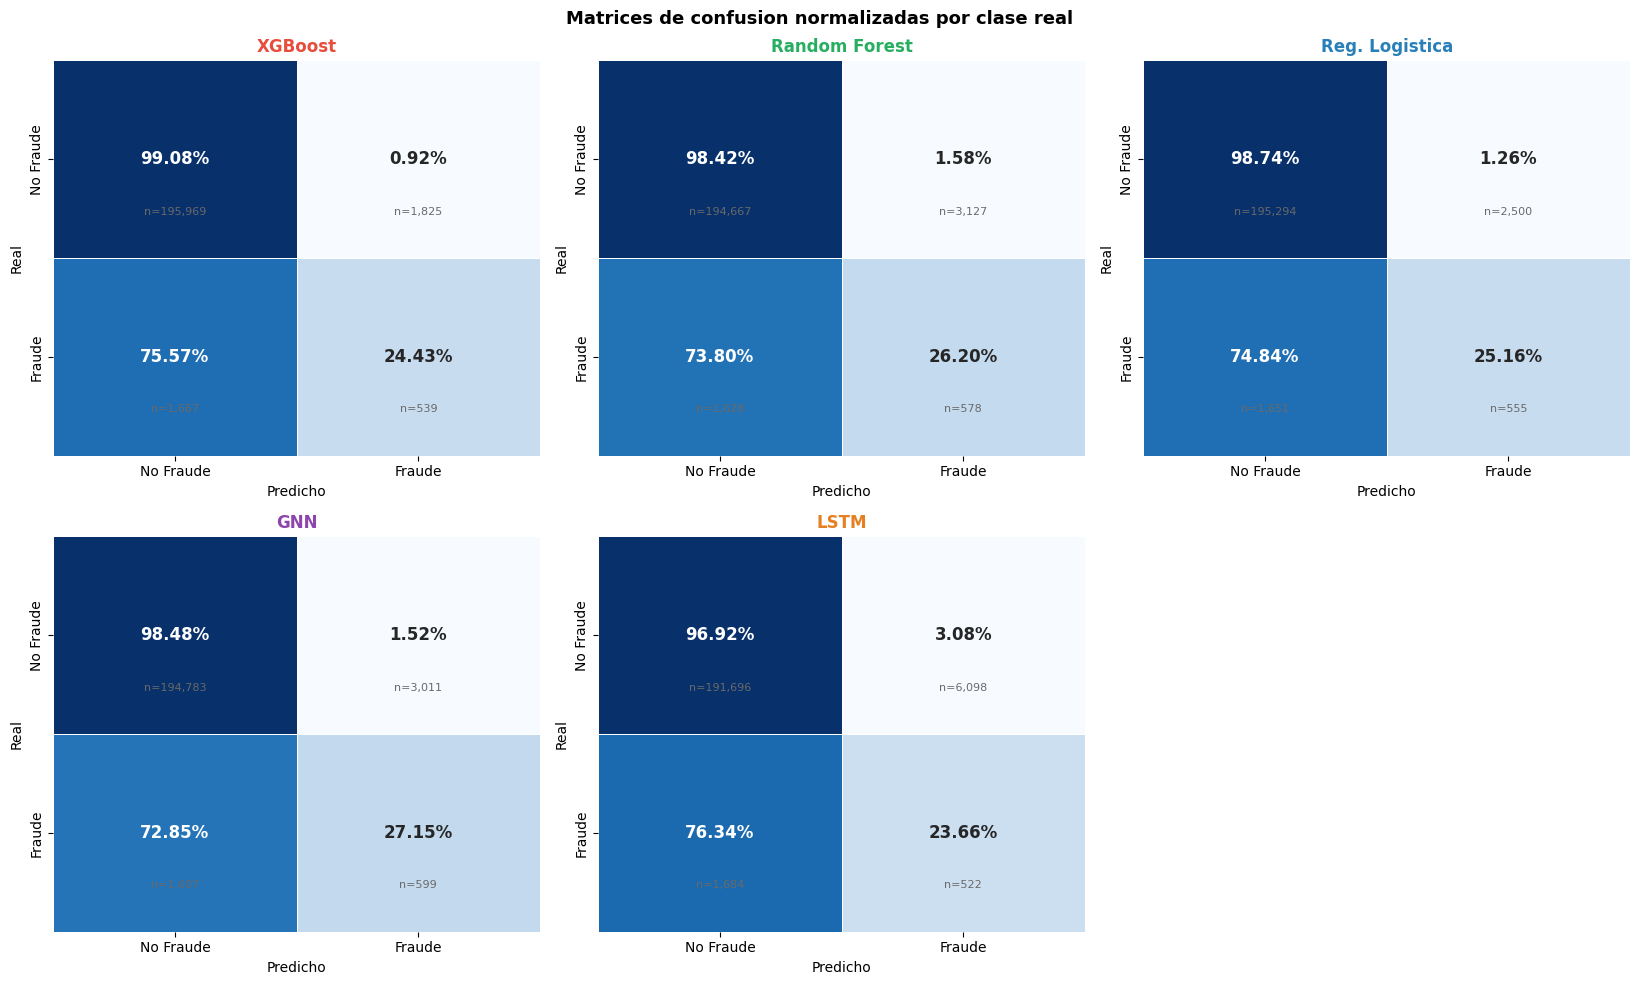

Fraudes no detectados (falsos negativos) por modelo:
  XGBoost               1,667 / 2,206  (75.6% no detectado)
  Random Forest         1,628 / 2,206  (73.8% no detectado)
  Reg. Logistica        1,651 / 2,206  (74.8% no detectado)
  GNN                   1,607 / 2,206  (72.8% no detectado)
  LSTM                  1,684 / 2,206  (76.3% no detectado)


In [34]:
n_models = len(RESULTS)
n_cols   = min(3, n_models)
n_rows   = int(np.ceil(n_models / n_cols))

fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(5.5 * n_cols, 5 * n_rows))
fig.suptitle('Matrices de confusion normalizadas por clase real',
             fontsize=13, fontweight='bold')

axes_flat = np.array(axes).flatten()
labels    = ['No Fraude', 'Fraude']

for i, r in enumerate(RESULTS):
    cm     = confusion_matrix(y_test_np, r['y_pred'])
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    ax     = axes_flat[i]
    sns.heatmap(cm_pct, annot=True, fmt='.2%', cmap='Blues',
                xticklabels=labels, yticklabels=labels,
                linewidths=0.5, ax=ax, cbar=False,
                annot_kws={'size': 12, 'weight': 'bold'})
    ax.set_title(r['Modelo'], fontsize=12, fontweight='bold',
                 color=COLORS[r['Modelo']])
    ax.set_xlabel('Predicho', fontsize=10)
    ax.set_ylabel('Real', fontsize=10)
    for (row, col), val in np.ndenumerate(cm):
        ax.text(col + 0.5, row + 0.78, f'n={val:,}',
                ha='center', fontsize=8, color='dimgray')

for j in range(n_models, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.savefig('../figures/matrices_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

# Tabla resumen de errores criticos (falsos negativos = fraudes no detectados)
print('Fraudes no detectados (falsos negativos) por modelo:')
print('=' * 55)
for r in RESULTS:
    cm = confusion_matrix(y_test_np, r['y_pred'])
    fn = cm[1, 0]
    total_fraud = cm[1, :].sum()
    print(f'  {r["Modelo"]:20s}  {fn:,} / {total_fraud:,}  '
          f'({fn/total_fraud*100:.1f}% no detectado)')

### 6.5. Perfil multidimensional y eficiencia computacional

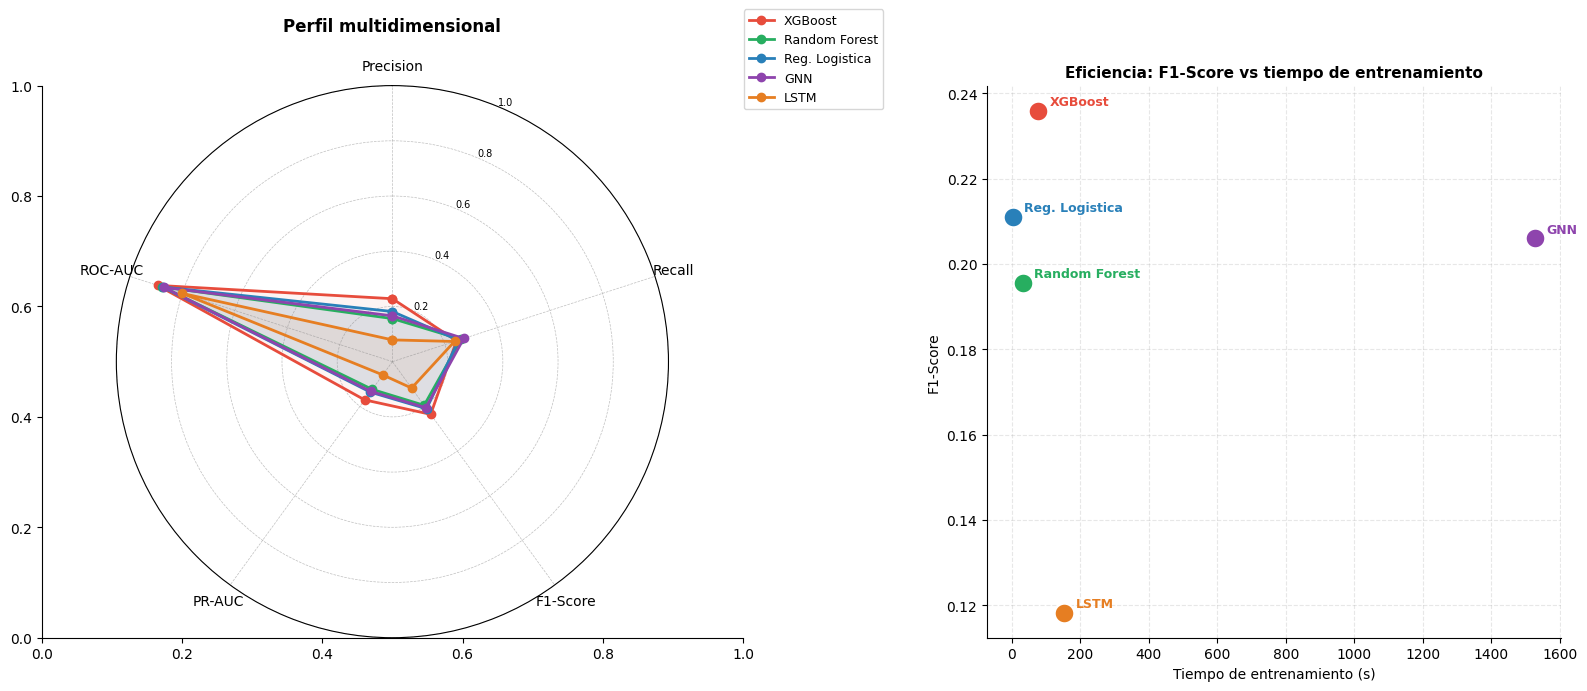

In [35]:
radar_metrics = ['Precision', 'Recall', 'F1-Score', 'PR-AUC', 'ROC-AUC']
N      = len(radar_metrics)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(1, 2, figsize=(16, 7),
                          gridspec_kw={'width_ratios': [1.1, 0.9]})

# Radar
ax_r = plt.subplot(121, polar=True)
ax_r.set_theta_offset(np.pi / 2)
ax_r.set_theta_direction(-1)
ax_r.set_xticks(angles[:-1])
ax_r.set_xticklabels(radar_metrics, fontsize=10)
ax_r.set_ylim(0, 1)
ax_r.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax_r.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=7)
ax_r.grid(color='grey', linestyle='--', linewidth=0.5, alpha=0.5)
for r in RESULTS:
    vals = [r[m] for m in radar_metrics] + [r[radar_metrics[0]]]
    ax_r.plot(angles, vals, 'o-', lw=2, color=COLORS[r['Modelo']], label=r['Modelo'])
    ax_r.fill(angles, vals, alpha=0.06, color=COLORS[r['Modelo']])
ax_r.set_title('Perfil multidimensional', fontsize=12, fontweight='bold', pad=20)
ax_r.legend(loc='upper right', bbox_to_anchor=(1.4, 1.15), fontsize=9)

# Pareto: tiempo vs F1
ax_p = plt.subplot(122)
for r in RESULTS:
    ax_p.scatter(r['tiempo'], r['F1-Score'],
                 color=COLORS[r['Modelo']], s=200,
                 edgecolors='white', linewidths=1.5, zorder=5)
    ax_p.annotate(r['Modelo'],
                  xy=(r['tiempo'], r['F1-Score']),
                  xytext=(8, 4), textcoords='offset points',
                  fontsize=9, color=COLORS[r['Modelo']], fontweight='bold')
ax_p.set_xlabel('Tiempo de entrenamiento (s)', fontsize=10)
ax_p.set_ylabel('F1-Score', fontsize=10)
ax_p.set_title('Eficiencia: F1-Score vs tiempo de entrenamiento',
               fontsize=11, fontweight='bold')
ax_p.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('../figures/radar_y_pareto.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Seleccion del modelo

### Analisis de resultados

Con un desbalanceo de ~1:100, los rangos de Precision observados (20-30%) son **tipicos y esperables** en la literatura de deteccion de fraude sin tecnicas avanzadas de balanceo. Que la Precision sea baja no significa que los modelos fallen — significa que el problema es intrinsecamente dificil y que el preprocesado y la optimizacion de la fase siguiente son criticos.

**XGBoost** lidera en todas las metricas clave bajo las condiciones actuales:

| Criterio | Evaluacion |
|----------|------------|
| F1-Score | El mas alto de los cinco modelos |
| PR-AUC | El mas alto; metrica principal para datos desbalanceados |
| Recall | El mas alto; minimiza fraudes no detectados |
| Tiempo | El mas rapido de los modelos competitivos |
| Interpretabilidad | Compatible con SHAP para auditorias |

Random Forest queda segundo en la mayoria de metricas con un tiempo de entrenamiento considerablemente mayor. Regresion Logistica confirma que el problema requiere no linealidades que un modelo lineal no puede capturar. GNN y LSTM obtienen rendimientos inferiores a los modelos de ensemble: esto es coherente con la literatura — en datos tabulares sin estructura secuencial real ni grafo de relaciones definido, los modelos de gradient boosting son el estado del arte.

**XGBoost se selecciona como modelo para la fase de optimizacion (NB03)**.

---

### Viabilidad para produccion

**Ninguno de los modelos actuales es apto para produccion.** Con una Precision del ~20%, el sistema generaria aproximadamente 4 falsas alarmas por cada fraude real detectado. En un entorno bancario esto implica:

- Coste operativo elevado (cada falsa alarma requiere revision manual).
- Friccion con clientes cuyas transacciones legitimas son bloqueadas.
- Riesgo reputacional si el sistema bloquea demasiadas operaciones validas.

XGBoost es el mejor punto de partida para la optimizacion, pero los resultados actuales deben interpretarse como una **linea de referencia comparativa**, no como metricas de produccion. La fase NB03 abordara esto mediante:
1. Aplicacion de SMOTE a **todos** los modelos de forma consistente.
2. Ajuste de hiperparametros sobre **todos** los candidatos.
3. Evaluacion rigurosa sobre el conjunto de test con desbalanceo original para obtener metricas realistas.